# Reddit Research: Taoism

## 3. Topic Labeling

This notebook performs an unsupervised thematic and rhetorical analysis of Reddit comments related to Taoism. First, the comments are clustered using sentence embeddings and KMeans to identify emergent thematic groups. Each cluster is then labeled using GPT-4, based on representative examples. In the second stage, each topic is mapped to one of five rhetorical categories—Identity, Community, Network, Authority, or Blurring Online/Offline—based on the framework proposed by Campbell and Teusner (2015). These rhetorical categories describe how religious expression is shaped in digital environments. The final result is a labeled dataset where each comment is assigned both a topic and a rhetorical function, enabling both quantitative and qualitative analysis of online Taoist discourse.

In [138]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

In [134]:
# Load preprocessed Reddit comments
comments_df = pd.read_csv("../data/taoism_comments_cleaned.csv")
comments_df.head()

,post_id,comment_id,parent_id,author,body,score,created_utc,depth,clean_text,original_length,clean_length,word_count
0,1kn2via,msf3jdu,t3_1kn2via,whatthebosh,Everything is as it is. If you feel moved to h...,32,1.747300e+09,0,feel move help man tear sound horrible simply ...,102,34,34
1,1kn2via,msez1as,t3_1kn2via,ZipMonk,It's not about good and evil those are Abraham...,26,1.747297e+09,0,good evil abrahamic concept,10,4,4
2,1kn2via,msezcku,t3_1kn2via,Yous1ash,Buddhism is much more equipped to deal with su...,25,1.747297e+09,0,buddhism equipped deal suffering experience st...,31,14,14
3,1kn2via,msf2ald,t3_1kn2via,jacques-vache-23,Why do you walk by? The moment was there and ...,20,1.747299e+09,0,walk moment let pass move,25,5,5
4,1kn2via,msfl533,t3_1kn2via,yellowlotusx,"Today, i went to the spots where hobos and add...",7,1.747309e+09,0,today go spot hobo addict hang give strawberry...,44,21,21


This cell loads the "all-mpnet-base-v2" pre-trained model from the sentence-transformers library. It's optimized for producing high-quality semantic vector embeddings for sentences, which will be used for clustering and topic modeling later.

In [141]:
# Load sentence transformer model
embedding_model = SentenceTransformer("all-mpnet-base-v2")

# Generate document embeddings
embeddings = embedding_model.encode(texts_cleaned, show_progress_bar=True)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In this cell, we are going to evaluate the optimal number of clusters for our KMeans model by calculating the Silhouette Score for each value of 
𝑘 between 5 and 35. For each 𝑘, we fit the model to our sentence embeddings and store the resulting score, which indicates how well the data points fit within their assigned clusters compared to others. Finally, we plot these scores to visualize how clustering quality varies across different values of 
𝑘, helping us decide on a suitable number of clusters for our topic modeling.

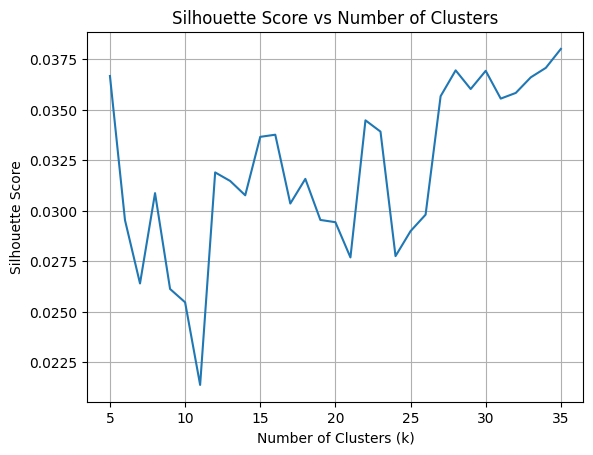

In [161]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []
range_k = range(5, 36)

for k in range_k:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    scores.append(score)

plt.plot(range_k, scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

In [170]:
num_clusters = 15

# Fit KMeans
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
comments_df["cluster"] = kmeans.fit_predict(embeddings)

# Evaluating the Silhouette Score
score = silhouette_score(embeddings, comments_df["cluster"])
print(f"Silhouette Score: {score:.2f}")

Silhouette Score: 0.03


We can see how the Silhouette Score varies depending on the number of clusters used in the KMeans algorithm. Although the highest scores appear in the range of 28 to 35 clusters, we noticed that these may lead to overly fragmented or redundant topics, especially when we later label them using GPT-4. For that reason, we decided to use 15 clusters, which strikes a balance between interpretability and clustering quality. In this cell, we apply KMeans with 𝑘=15, assign each comment to one of the resulting clusters, and compute the Silhouette Score to confirm that the clustering still performs reasonably well.

In [186]:
comments_df = comments_df.dropna(subset=["clean_text"]).reset_index(drop=True)

In [190]:
from sklearn.feature_extraction.text import TfidfVectorizer

# We show 5 comments and key words per cluster.
cluster_examples = {}

# We vectorize all texts using TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X_tfidf = vectorizer.fit_transform(comments_df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

for c in sorted(comments_df["cluster"].unique()):
    cluster_df = comments_df[comments_df["cluster"] == c]
    
    # Sample 5 example comments
    examples = cluster_df["body"].sample(5, random_state=42).tolist()
    
    # Subset TF-IDF matrix to the cluster
    cluster_tfidf = X_tfidf[cluster_df.index]
    mean_tfidf = cluster_tfidf.mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[::-1][:10]
    keywords = [feature_names[i] for i in top_indices]
    
    # Save in dictionary
    cluster_examples[c] = {
        "examples": examples,
        "keywords": keywords
    }

# Print to verify it worked
for c in list(cluster_examples.keys())[:3]:
    print(f"\nCluster {c} — Top keywords: {', '.join(cluster_examples[c]['keywords'])}")
    for i, ex in enumerate(cluster_examples[c]["examples"], 1):
        print(f"  {i}. {ex[:150]}...")



Cluster 0 — Top keywords: like, love, know, animal, water, day, sun, think, favorite, true
  1. As someone who's extremely far along this path, I can say, it's not "the answer" but there's not an answer I can't find by simply giving it breath att...
  2. How do you feel about it...
  3. Hi Ryokan1973!   Sorry for being "cheeky"... when I am in a good mood I tend to be.  I live in the US - more specifically in Vermont.  Congrats on bei...
  4. Fear of the unknown....
  5. Well both would have to sit down first, and tick which parts they wrote and which parts they didn't. THEN they could fight....

Cluster 1 — Top keywords: book, read, language, study, like, knowledge, text, talk, understand, way
  1. Excellent book. Thanks for the recommendation. I spent four days reading through it....
  2. I've just skimmed McDonald's translation, and I think there's competition for the worst translation of the DDJ, though, of course, Stephen Mitchell wo...
  3. The last name is Russian and very long

In [192]:
from openai import OpenAI
from dotenv import load_dotenv
import os

# Load API key from .env file
load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

def build_label_prompt(examples, keywords):
    comments_formatted = "\n".join([f"{i+1}. {ex}" for i, ex in enumerate(examples)])
    return f"""
You are contributing to an academic research project about online discourse and identity formation within Taoist communities on Reddit.

Below are 3 Reddit comments that have been grouped together using a semantic clustering algorithm. Your task is to analyze their shared meaning or communicative tone and generate a short, descriptive label for the cluster.

The label should be:
- concise (2–5 words),
- thematically or emotionally expressive,
- appropriate for use in a scholarly paper,
- and understandable to researchers and general readers alike.

Every cluster must be labeled, even if it seems incoherent, short, humorous, or dominated by emojis or interjections. In such cases, assign a label that best captures the communicative intent (e.g., “Emoji Affirmations”, “Brief Reactions”, “Off-Topic Jokes”).

Do not skip any cluster. Avoid general words like “Miscellaneous” or “Other.”

Respond only with the label. Do not include explanations or extra text.

Top Keywords: {", ".join(keywords)}

Comments:
{comments_formatted}
"""
    
client = OpenAI()

# Generate topic labels
cluster_labels = {}

for c, examples in cluster_examples.items():
    prompt = build_label_prompt(examples["examples"], examples["keywords"])
    
    response = client.chat.completions.create(
        model="gpt-4-turbo",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5
    )
    
    label = response.choices[0].message.content.strip()
    cluster_labels[c] = label


In [194]:
comments_df["topic_label"] = comments_df["cluster"].map(cluster_labels)
comments_df.to_csv("../data/taoism_comments_with_kmeans_topics.csv", index=False)

We want to visualize how many Reddit comments were assigned to each topic. The barplot helps us understand:
Which topics are dominant, Which are rare or possibly noisy, Whether our clustering was balanced or skewed.

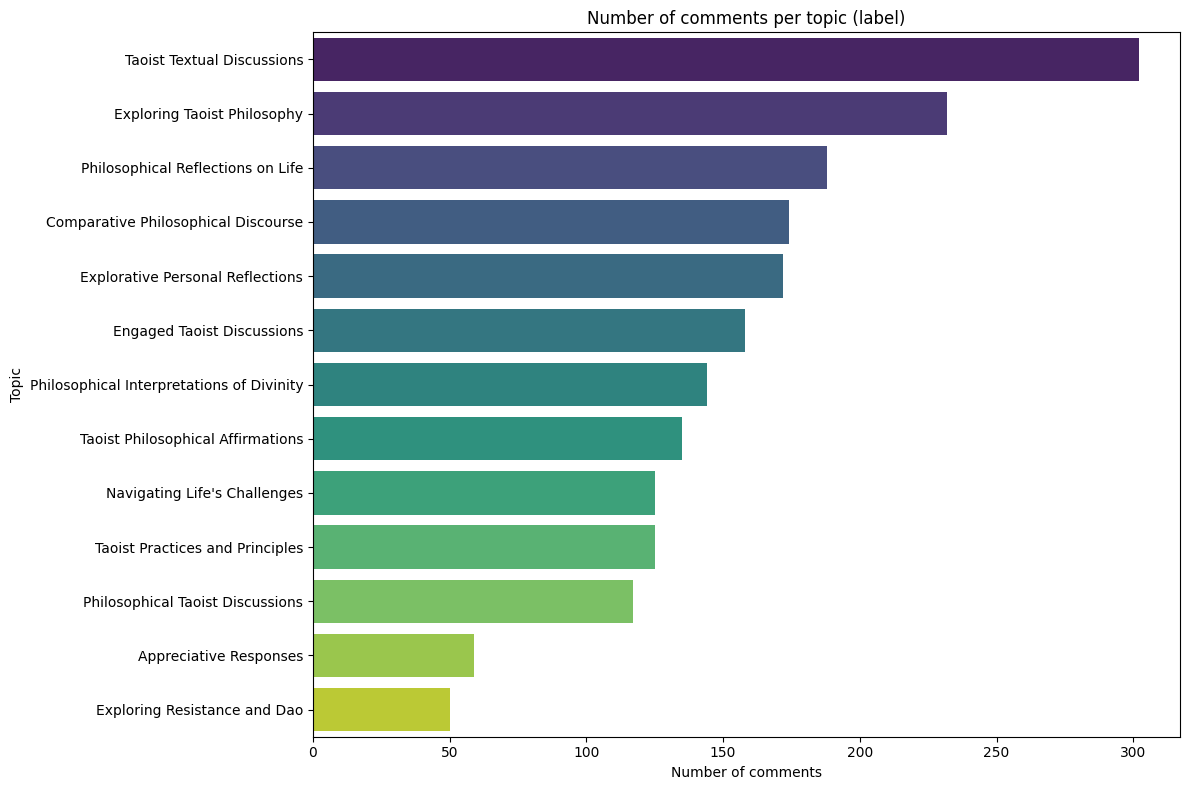

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

topic_counts = comments_df["topic_label"].value_counts().reset_index()
topic_counts.columns = ["topic_label", "count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=topic_counts, y="topic_label", x="count", hue="topic_label", legend=False, palette="viridis")
plt.title("Number of comments per topic (label)")
plt.xlabel("Number of comments")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


In [198]:
from openai import OpenAI
client = OpenAI()

# Collect all labels (assuming cluster_labels is a dict)
all_labels = list(cluster_labels.values())

# Format labels as a numbered list
formatted_labels = "\n".join([f"{i+1}. {label}" for i, label in enumerate(all_labels)])

# Build the prompt
merge_prompt = f"""
You are assisting with a qualitative analysis of Reddit discourse in Taoist communities.

Below is a list of 14 topic labels generated from semantic clustering and GPT-4 labeling of Reddit comments. Each label describes a distinct type of discourse theme.

Your task is to review this list and:
- Identify any semantically overlapping or redundant labels.
- Group similar ones under a **new, merged label** that better captures the shared meaning.
- Ensure the final list has **10 to 12 distinct themes**.
- Keep labels short (2–5 words), clear, and suitable for academic analysis.

Return the revised list, showing the original labels grouped under each merged label.

Original labels:
{formatted_labels}
"""

# Send to GPT
response = client.chat.completions.create(
    model="gpt-4-turbo",
    messages=[{"role": "user", "content": merge_prompt}],
    temperature=0.5
)

print(response.choices[0].message.content)


To consolidate the list of Reddit discourse themes into a more concise and distinct set, I have grouped similar themes and provided new labels that capture the shared essence of the discussions. Here is the revised list with explanations for the grouping:

**Merged Label: Taoist Philosophical Discussions**
- Taoist Textual Discussions
- Philosophical Taoist Discussions
- Engaged Taoist Discussions
- Taoist Philosophical Affirmations
- Exploring Taoist Philosophy
This label merges all discussions that focus on the philosophical aspects and interpretations of Taoism, whether they are based on texts or broader philosophical inquiry.

**Merged Label: Personal and Philosophical Reflections**
- Explorative Personal Reflections
- Philosophical Reflections on Life
These labels are combined as they both involve personal and philosophical insights into life from a Taoist perspective.

**Merged Label: Comparative and Interpretive Discourse**
- Comparative Philosophical Discourse
- Philosophical I

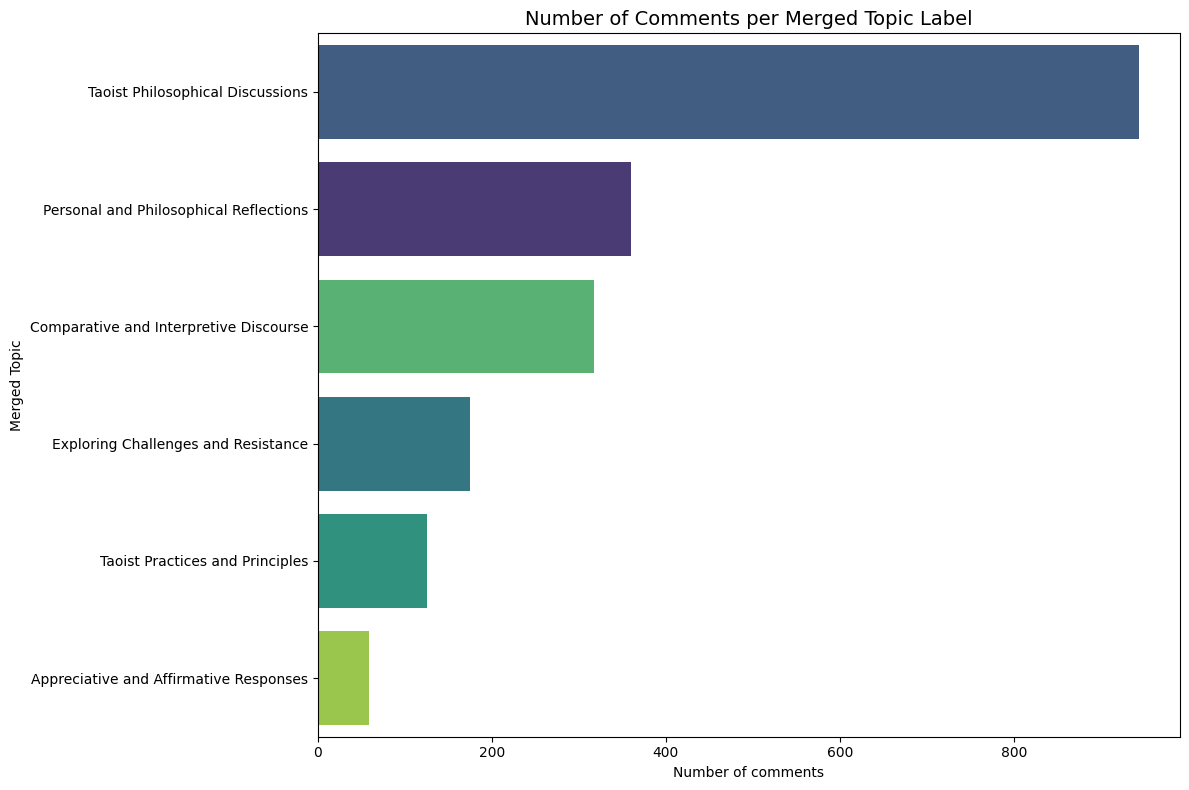

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map cluster numbers to their labels
comments_df["label"] = comments_df["cluster"].map(cluster_labels)

# Define the mapping from original GPT labels to merged labels
label_map = {
    "Taoist Textual Discussions": "Taoist Philosophical Discussions",
    "Philosophical Taoist Discussions": "Taoist Philosophical Discussions",
    "Engaged Taoist Discussions": "Taoist Philosophical Discussions",
    "Taoist Philosophical Affirmations": "Taoist Philosophical Discussions",
    "Exploring Taoist Philosophy": "Taoist Philosophical Discussions",

    "Explorative Personal Reflections": "Personal and Philosophical Reflections",
    "Philosophical Reflections on Life": "Personal and Philosophical Reflections",

    "Comparative Philosophical Discourse": "Comparative and Interpretive Discourse",
    "Philosophical Interpretations of Divinity": "Comparative and Interpretive Discourse",

    "Taoist Practices and Principles": "Taoist Practices and Principles",

    "Exploring Resistance and Dao": "Exploring Challenges and Resistance",
    "Navigating Life's Challenges": "Exploring Challenges and Resistance",

    "Appreciative Responses": "Appreciative and Affirmative Responses"
}

# Apply the merged label to the DataFrame
comments_df["merged_label"] = comments_df["label"].map(label_map)

# Plot
plt.figure(figsize=(12, 8))
sns.countplot(data=comments_df, y="merged_label", order=comments_df["merged_label"].value_counts().index, hue="merged_label", legend=False, palette="viridis")
plt.title("Number of Comments per Merged Topic Label", fontsize=14)
plt.xlabel("Number of comments")
plt.ylabel("Merged Topic")
plt.tight_layout()
plt.show()

In [206]:
# Save the DataFrame with merged labels
comments_df.to_csv("../data/taoism_comments_labeled.csv", index=False)
print("Saved to '../data/taoism_comments_labeled.csv'")

Saved to '../data/taoism_comments_labeled.csv'


In [208]:
# Show 3 example comments for each merged label
merged_examples = {}

for label in comments_df["merged_label"].dropna().unique():
    sample = comments_df[comments_df["merged_label"] == label]["body"].sample(3, random_state=42).tolist()
    merged_examples[label] = sample

# Print examples
for label, examples in merged_examples.items():
    print(f"\n=== {label} ===")
    for i, ex in enumerate(examples, 1):
        print(f"{i}. {ex[:200]}...")



=== Personal and Philosophical Reflections ===
1. One of my first issues is that in following dao we accord with nature. 

But the hours of a fixed time do not accord with nature any longer. 

Zi and Wu are energies in relation to true local midnight...
2. You're welcome, and dont take anyone or any text too seriously.

We are all just doing our own thing and often agree with each other but disagree just as much well.

Even the wise and "holy" teachers ...
3. I agree, it is a practice and an art to live well.

Though I would still hold that flowers bloom without needing to rewire anything.

Not saying we should necessarily envy flowers, and flowers are jus...

=== Taoist Philosophical Discussions ===
1. "We don't surrender power to emotions" is my added interpretation, because while "we don't have emotion" is technically the direct translation, its meaning (i.e. not letting emotional states jeopardiz...
2. Interesting, I didn't know that....
3. Most of the available texts are availabl

In the previous steps, we labeled the 15 clusters generated through semantic embedding and KMeans clustering by selecting representative examples from each group and using GPT-4 to assign concise, descriptive topic labels. To improve clarity and avoid redundancy, we then analyzed the resulting labels and identified overlapping or semantically similar themes. Using GPT-4 again, we consolidated the original 14 labels into six broader, non-overlapping categories that better reflect the dominant patterns of discourse in the Reddit Taoism community. This step enhances the interpretability of our analysis and supports a clearer thematic structure for further qualitative exploration.

Next, we will assign each topic cluster to one of Campbell and Teusner’s (2015) five rhetorical frames of digital religion: Identity, Community, Network, Authority, and Blurring Online/Offline. Rather than classifying each individual comment, which would be more granular but also far more costly and computationally intensive, we opted to categorize rhetoric at the cluster level. This approach allows us to capture the dominant communicative tone of each thematic group based on representative examples. While this method may overlook rhetorical variation within clusters, it offers a cost-efficient solution that preserves the interpretability and structure of the discourse. Classifying nearly 2,000 comments individually would require over $50 in GPT-4 API usage, compared to less than one dollar using cluster-level prompts. This trade-off favors thematic clarity over granularity and supports the broader aims of this analysis.

In [211]:
from openai import OpenAI
import time

# Initialize GPT-4 client
client = OpenAI()

# Dictionary to store mappings
rhetoric_mappings = {}

# Define the rhetoric categories
rhetoric_intro = """
You are assisting in an academic research project about digital religion. Below is a topic label and a set of representative Reddit comments from a Taoist community. Your task is to assign the most appropriate rhetorical frame from the typology developed by Campbell and Teusner (2015).

Choose *only one* of the following rhetorical categories:

1. **Identity** – When discourse involves experimenting with or asserting personal or spiritual identity. Look for signs of self-reflection, belief formation, or individual expressions of Taoist values and meaning.
2. **Community** – When discourse emphasizes belonging, mutual support, group interaction, shared values, or cultivation of emotional bonds. It may contain testimonies, encouragement, or communal rituals.
3. **Network** – When discourse references broader affiliations, cross-group dialogue, decentralized structures, or displays multi-belonging and linkages to other ideas or sources. It emphasizes fluid, flexible connection over fixed identity.
4. **Authority** – When discourse challenges, negotiates, or reinforces religious knowledge, legitimacy, hierarchy, or interpretive power. It can include citation of texts, questioning of interpretations, or gatekeeping behavior.
5. **Blurring Online/Offline** – When discourse integrates offline experiences into the digital context or shows how online participation relates to embodied, real-life spiritual practice.

**Instructions:**
- Read the topic label and the six sample comments.
- Choose the one rhetorical frame that best applies.
- After the category name, provide a short explanation (2–3 sentences) of why this topic fits that frame.
- Be clear and concise. Do not include more than one category.

"""

# Loop through each merged topic label
for label in comments_df["merged_label"].dropna().unique():
    sample = comments_df[comments_df["merged_label"] == label]["body"].sample(6, random_state=42).tolist()

    # Construct the prompt
    prompt = f"""{rhetoric_intro}

Topic label: "{label}"

Example comments:
1. {sample[0]}
2. {sample[1]}
3. {sample[2]}
4. {sample[3]}
5. {sample[4]}
6. {sample[5]}

What is the most appropriate rhetoric category and why?
"""
    
    # Send to GPT-4
    try:
        response = client.chat.completions.create(
            model="gpt-4-turbo",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.4
        )

        result = response.choices[0].message.content.strip()
        rhetoric_mappings[label] = result
        time.sleep(1) 
    except Exception as e:
        print(f"Error for topic {label}: {e}")


Once we have received the responses from GPT-4 for each topic, we need to extract the actual rhetoric category (e.g., Identity, Community, etc.) from GPT’s output. In the previous cell, GPT returned a paragraph with both the category and a short explanation in free text format. Now, we want to systematically extract just the name of the category for each topic and store it in a new dictionary. This will make it easier to merge that information back into our main DataFrame. In this cell, we loop through the dictionary of GPT responses (rhetoric_mappings), and for each one, we extract the first word in the string, assuming that GPT answered in the format: “Identity: explanation...” or “Community – because...”. We use a regular expression to capture only the category name and store it in a new dictionary called rhetoric_labels_cleaned, where each topic label is mapped to just the cleaned category. This prepares the data for integration into the main dataset.

In [219]:
# Display GPT-4 outputs for manual inspection
for topic, response in rhetoric_mappings.items():
    print(f"\n=== Topic: {topic} ===")
    print(response)



=== Topic: Personal and Philosophical Reflections ===
**Identity** – The comments under the topic label "Personal and Philosophical Reflections" primarily focus on individual expressions of Taoist values and meaning, self-reflection, and belief formation. The comments explore personal interpretations and applications of Taoist principles, such as the alignment with nature, the questioning of traditional practices (like BaZi timing systems), and personal advice on spiritual practice. Each comment reflects a personal journey or viewpoint, emphasizing the exploration and assertion of individual spiritual identity within the framework of Taoist thought.

=== Topic: Taoist Philosophical Discussions ===
**Authority** – The comments in this topic primarily engage with the interpretation and understanding of Taoist philosophy, which aligns with the rhetorical frame of Authority. In these discussions, users are either interpreting Taoist texts (as seen in comment 1), questioning or reflecting 

In [223]:
import re

# Extract rhetoric label (the word inside the ** ** at the start of each output)
rhetoric_label_map = {}

for label, full_response in rhetoric_mappings.items():
    match = re.match(r"\*\*(.*?)\*\*", full_response)
    if match:
        rhetoric_label_map[label] = match.group(1).strip()
    else:
        print(f"Could not extract rhetoric for: {label}")

# Map rhetoric back to the DataFrame
comments_df["rhetoric"] = comments_df["merged_label"].map(rhetoric_label_map)

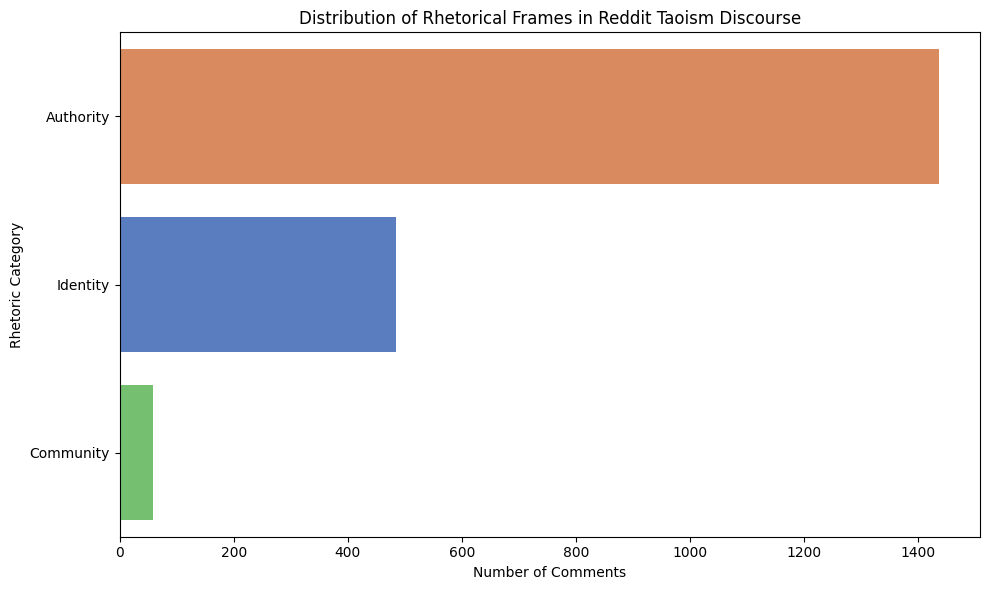

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=comments_df, y="rhetoric", order=comments_df["rhetoric"].value_counts().index, hue="rhetoric", legend=False, palette="muted")
plt.title("Distribution of Rhetorical Frames in Reddit Taoism Discourse")
plt.xlabel("Number of Comments")
plt.ylabel("Rhetoric Category")
plt.tight_layout()
plt.show()


Para terminar  amos a comprobar que todos los comentarios han sido debidamente etiquetados y asignados a una categoria retorica. Una vez hecho esto, guardaremos el resultado de la clasificacion y procederemos a otra etapa del analisis de nuestro dataset.

In [231]:
# Check for missing topic labels
missing_topics = comments_df["topic_label"].isna().sum()

# Check for missing or unclear rhetoric labels
missing_rhetoric = comments_df["rhetoric"].isna().sum()
unclear_rhetoric = (comments_df["rhetoric"] == "Unclear").sum()

print(f"Missing topic labels: {missing_topics}")
print(f"Missing rhetoric labels: {missing_rhetoric}")
print(f"Unclear rhetoric labels: {unclear_rhetoric}")

Missing topic labels: 0
Missing rhetoric labels: 0
Unclear rhetoric labels: 0


In [233]:
# Save final version of the labeled dataset
comments_df.to_csv("../data/taoism_comments_labeled_rhetoric.csv", index=False)
print("Saved to '../data/taoism_comments_labeled_rhetoric.csv'")

Saved to '../data/taoism_comments_labeled_rhetoric.csv'


In this notebook, we performed topic modeling on a set of Reddit comments from Taoist communities using semantic embeddings and KMeans clustering. Each cluster was labeled using GPT-4, and overlapping labels were merged into broader thematic categories to enhance interpretability. We then used representative comments from each merged topic to assign one of five rhetorical frames based on Campbell and Teusner’s (2015) typology of digital religion. These frames—Identity, Community, Network, Authority, and Blurring Online/Offline—allowed us to interpret how discourse within the subreddit contributes to the construction of religious meaning and practice online. Our results suggest a dominant rhetorical focus on Authority, followed by Identity, with Community appearing to a lesser extent. The final dataset includes topic labels, merged themes, and rhetorical categories for each comment, enabling future qualitative and quantitative analyses.